
RMSE = 2.3135

Función ajustada:

f(PWM, V) = 456.549738 + (-6.166912e-14)*PWM + (-7.865743e-14)*Voltage + (-5.991420e-09)*PWM^2 + (-1.071085e-13)*PWM Voltage + (7.001262e-17)*Voltage^2 + (7.789597e-13)*PWM^3 + (-2.578239e-08)*PWM^2 Voltage + (2.240971e-12)*PWM Voltage^2 + (8.129071e-16)*Voltage^3 + (-2.580383e-18)*PWM^4 + (3.706487e-14)*PWM^3 Voltage + (1.572554e-09)*PWM^2 Voltage^2 + (4.226289e-11)*PWM Voltage^3 + (8.362284e-15)*Voltage^4

Ejemplo:
456.52602651466174


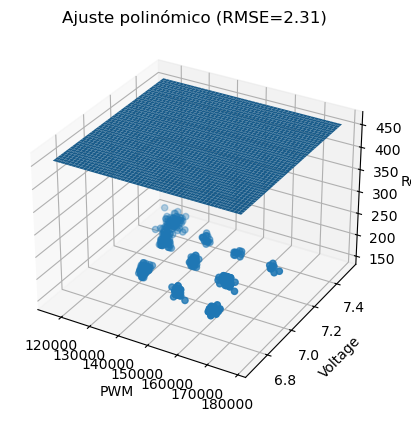

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Cargar datos
# ----------------------------
df = pd.read_csv("datos_vuelo_pesos_04.27.26.txt", sep="\t")

X = df[["PWM", "Voltage"]].values
y = df["Real"].values

# ----------------------------
# Parámetros
# ----------------------------
grado_pwm = 1
grado_voltaje = 3
grado_total = max(grado_pwm, grado_voltaje)

poly = PolynomialFeatures(degree=grado_total, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["PWM", "Voltage"])

# ----------------------------
# Filtrado de términos
# ----------------------------
def filtrar_features(feature_names, grado_pwm, grado_voltaje):
    seleccion = []
    for i, name in enumerate(feature_names):
        grado_pwm_i = name.count("PWM")
        grado_volt_i = name.count("Voltage")

        if grado_pwm_i <= grado_pwm and grado_volt_i <= grado_voltaje:
            seleccion.append(i)
    return seleccion

indices = filtrar_features(feature_names, grado_pwm, grado_voltaje)

X_poly_filtrado = X_poly[:, indices]
feature_names_filtrado = feature_names[indices]

# ----------------------------
# Ajuste
# ----------------------------
modelo = LinearRegression()
modelo.fit(X_poly_filtrado, y)

# ----------------------------
# RMSE
# ----------------------------
y_pred = modelo.predict(X_poly_filtrado)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nRMSE = {rmse:.4f}")


# ----------------------------
# Mostrar ecuación
# ----------------------------
print("\nFunción ajustada:\n")
ecuacion = f"{modelo.intercept_:.6f}"

for coef, name in zip(modelo.coef_, feature_names_filtrado):
    ecuacion += f" + ({coef:.6e})*{name}"

print("f(PWM, V) =", ecuacion)

# ----------------------------
# Función evaluable
# ----------------------------
def f(PWM, V):
    vals = []
    for name in feature_names_filtrado:
        val = 1
        if "PWM" in name:
            val *= PWM ** name.count("PWM")
        if "Voltage" in name:
            val *= V ** name.count("Voltage")
        vals.append(val)
    return modelo.intercept_ + np.dot(modelo.coef_, vals)

# Ejemplo
print("\nEjemplo:")
print(f(130000, 7.3))




# ----------------------------
# Superficie 3D
# ----------------------------
# Rango de valores
pwm_range = np.linspace(df["PWM"].min(), df["PWM"].max(), 50)
volt_range = np.linspace(df["Voltage"].min(), df["Voltage"].max(), 50)

PWM_grid, V_grid = np.meshgrid(pwm_range, volt_range)

Z = np.zeros_like(PWM_grid)

for i in range(PWM_grid.shape[0]):
    for j in range(PWM_grid.shape[1]):
        Z[i, j] = f(PWM_grid[i, j], V_grid[i, j])

# ----------------------------
# Gráfica
# ----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Superficie
ax.plot_surface(PWM_grid, V_grid, Z)

# Puntos reales
ax.scatter(df["PWM"], df["Voltage"], df["Real"])

ax.set_xlabel("PWM")
ax.set_ylabel("Voltage")
ax.set_zlabel("Real")

plt.title(f"Ajuste polinómico (RMSE={rmse:.2f})")
plt.show()